# Arabic Word Recognition
### Single-class YOLO (find characters) + CNN (classify characters)
#### Dataset: my own handwritten words labelled in Label Studio

## 1. Install & Import

In [1]:
!pip install ultralytics opencv-python-headless matplotlib scikit-learn tensorflow Pillow tqdm seaborn

In [2]:
import os, shutil, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Dense, Dropout,
    BatchNormalization, Flatten, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.21.0
GPU available: False


In [3]:
from pathlib import Path
import cv2
import numpy as np

MY_DATASET  = Path(r"F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset")
OUTPUT_DIR  = Path(r"F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_chars")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load class names from your Label Studio export
classes_file = MY_DATASET / "classes.txt"
classes = [l.strip() for l in classes_file.read_text().splitlines() if l.strip()]
print(f"Classes: {classes}")

count = 0
for split in ['train', 'val']:
    img_dir = MY_DATASET / split / 'images'
    lbl_dir = MY_DATASET / split / 'labels'

    for img_path in sorted(img_dir.glob('*.*')):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if not lbl_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        H, W = img.shape[:2]

        for line in lbl_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            class_id = int(parts[0])
            x_c, y_c, bw, bh = map(float, parts[1:5])

            # Convert YOLO normalized coords to pixel coords
            x1 = int((x_c - bw/2) * W)
            y1 = int((y_c - bh/2) * H)
            x2 = int((x_c + bw/2) * W)
            y2 = int((y_c + bh/2) * H)

            # Clamp to image bounds
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(W, x2), min(H, y2)

            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            # Save crop into a subfolder named after the class
            label = classes[class_id]
            out_dir = OUTPUT_DIR / label
            out_dir.mkdir(exist_ok=True)
            out_path = out_dir / f"{img_path.stem}_{count:04d}.png"
            cv2.imwrite(str(out_path), crop)
            count += 1

print(f"\nExtracted {count} character crops to {OUTPUT_DIR}")
print("Subfolders created:")
for d in sorted(OUTPUT_DIR.iterdir()):
    imgs = list(d.glob('*.png'))
    print(f"  {d.name}: {len(imgs)} images")

Classes: ['ain_begin', 'ain_end', 'ain_middle', 'ain_regular', 'alif_end', 'alif_hamza', 'alif_regular', 'beh_begin', 'beh_end', 'beh_middle', 'beh_regular', 'dad_begin', 'dad_end', 'dad_middle', 'dad_regular', 'dal_end', 'dal_regular', 'feh_begin', 'feh_end', 'feh_middle', 'feh_regular', 'ghain_begin', 'ghain_end', 'ghain_middle', 'ghain_regular', 'hah_begin', 'hah_end', 'hah_middle', 'hah_regular', 'hamza', 'heh_begin', 'heh_end', 'heh_middle', 'heh_regular', 'jeem_begin', 'jeem_end', 'jeem_middle', 'jeem_regular', 'kaf_begin', 'kaf_end', 'kaf_middle', 'kaf_regular', 'khah_begin', 'khah_end', 'khah_middle', 'khah_regular', 'lam_alif', 'lam_begin', 'lam_end', 'lam_middle', 'lam_regular', 'meem_begin', 'meem_end', 'meem_middle', 'meem_regular', 'noon_begin', 'noon_end', 'noon_middle', 'noon_regular', 'qaf_begin', 'qaf_end', 'qaf_middle', 'qaf_regular', 'raa_end', 'raa_regular', 'sad_begin', 'sad_end', 'sad_middle', 'sad_regular', 'seen_begin', 'seen_end', 'seen_middle', 'seen_regular',

## 2. Paths

In [4]:
ROOT       = Path(r"F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN")
AHAWP_DIR  = ROOT / "isolated_alphabets_per_alphabet"
MY_DATASET = ROOT / "my_dataset"
MY_CHARS   = ROOT / "my_chars"
IMG_SIZE   = 64

for p in [ROOT, AHAWP_DIR, MY_DATASET]:
    print(f"{'OK' if p.exists() else 'MISSING'}: {p}")

OK: F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN
OK: F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\isolated_alphabets_per_alphabet
OK: F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset


## 3. CNN Training — Character Classifier
Trained on isolated characters. Uses grayscale 64×64 input.

In [8]:
FORM_MAP = {
    'begin':   'beginning',
    'middle':  'middle',
    'end':     'end',
    'regular': 'isolated',
    'hamza':   'hamza',
    'alif':    'alif',
}

def load_isolated_dataset(alphabets_dir, img_size=IMG_SIZE):
    """Loads from AHAWP-style folders: ain_begin, beh_middle etc."""
    images, labels = [], []
    for subfolder in sorted(alphabets_dir.iterdir()):
        if not subfolder.is_dir():
            continue
        parts = subfolder.name.rsplit('_', 1)
        if len(parts) != 2:
            continue
        letter, form_raw = parts
        form = FORM_MAP.get(form_raw)
        if form is None:
            continue
        label = letter  # Use base letter only, not form
        for img_path in sorted(subfolder.glob("*.png")):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label)
    X = np.array(images, dtype='float32') / 255.0
    X = X[..., np.newaxis]
    y = np.array(labels)
    print(f"Loaded {len(X)} images across {len(set(labels))} classes")
    return X, y


# Load only AHAWP dataset (NO my_chars) - more samples, printed but consistent
X_all, y_all = load_isolated_dataset(AHAWP_DIR)
print(f"\nCombined: {len(X_all)} images")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_all)
NUM_CLASSES = len(le.classes_)
ARABIC_LABELS = list(le.classes_)

np.save("label_classes.npy", le.classes_)
print(f"Classes: {NUM_CLASSES}")
print(ARABIC_LABELS)

Loaded 53199 images across 18 classes

Combined: 53199 images
Classes: 18
[np.str_('ain'), np.str_('alif'), np.str_('beh'), np.str_('dal'), np.str_('feh'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('raa'), np.str_('sad'), np.str_('seen'), np.str_('tah'), np.str_('waw'), np.str_('yaa')]


X_all shape: (53199, 64, 64, 1)
y_all unique labels: 18
Sample labels: ['ain' 'ain' 'ain' 'ain' 'ain' 'ain' 'ain' 'ain' 'ain' 'ain']


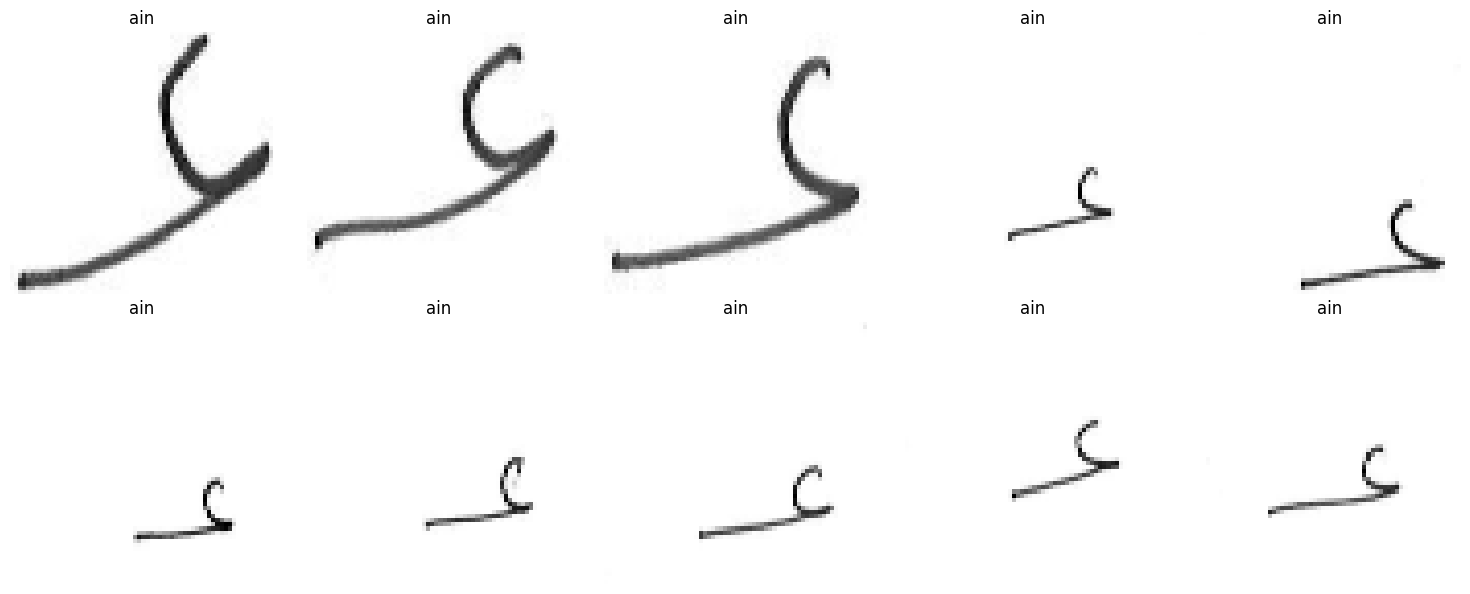

In [9]:
# Debug: Visualize some loaded images to check data quality
import matplotlib.pyplot as plt

print(f"X_all shape: {X_all.shape}")
print(f"y_all unique labels: {len(set(y_all))}")
print(f"Sample labels: {y_all[:10]}")

# Show first 10 images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(X_all[i].squeeze(), cmap='gray')
    ax.set_title(f"{y_all[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
from collections import Counter

# Handle rare classes with <2 examples (can't stratify with those)
counts = Counter(y_encoded)
keep_classes = {cls for cls, n in counts.items() if n >= 2}
if len(keep_classes) < len(counts):
    mask = np.array([y in keep_classes for y in y_encoded])
    dropped = sorted(set(y_encoded) - keep_classes)
    X_all = X_all[mask]
    y_encoded = y_encoded[mask]
    print(f"Dropped {len(dropped)} too-rare classes with <2 samples: {dropped}")

# first split with stratify
stratify_vals = y_encoded if len(np.unique(y_encoded)) > 1 else None
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_encoded, test_size=0.25, random_state=SEED, stratify=stratify_vals
)

# second split: only stratify when every class has >=2 samples, otherwise plain split
counts_temp = Counter(y_temp)
if min(counts_temp.values()) >= 2 and len(np.unique(y_temp)) > 1:
    stratify_vals_temp = y_temp
    print("Using stratified split for validation/test")
else:
    stratify_vals_temp = None
    print("Falling back to non-stratified split for validation/test due to rare classes in temp")

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=stratify_vals_temp
)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Using stratified split for validation/test
Train: (39899, 64, 64, 1)  Val: (6650, 64, 64, 1)  Test: (6650, 64, 64, 1)


In [11]:
from collections import Counter

print("Class distribution in combined dataset:")
class_counts = Counter(y_all)
for label, count in sorted(class_counts.items()):
    print(f"{label}: {count}")

# Check if any class dominates
total = sum(class_counts.values())
for label, count in sorted(class_counts.items()):
    pct = (count / total) * 100
    print(f"{label}: {count} ({pct:.1f}%)")

Class distribution in combined dataset:
ain: 3280
alif: 2460
beh: 3280
dal: 1640
feh: 3250
heh: 3260
jeem: 3280
kaf: 3280
lam: 4100
meem: 3280
noon: 3250
qaf: 3260
raa: 1640
sad: 3279
seen: 3280
tah: 2460
waw: 1640
yaa: 3280
ain: 3280 (6.2%)
alif: 2460 (4.6%)
beh: 3280 (6.2%)
dal: 1640 (3.1%)
feh: 3250 (6.1%)
heh: 3260 (6.1%)
jeem: 3280 (6.2%)
kaf: 3280 (6.2%)
lam: 4100 (7.7%)
meem: 3280 (6.2%)
noon: 3250 (6.1%)
qaf: 3260 (6.1%)
raa: 1640 (3.1%)
sad: 3279 (6.2%)
seen: 3280 (6.2%)
tah: 2460 (4.6%)
waw: 1640 (3.1%)
yaa: 3280 (6.2%)


In [12]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    """Larger CNN for better capacity."""
    model = Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv2D(32, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2),
        Dropout(0.2),

        # Block 2
        Conv2D(64, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2),
        Dropout(0.2),

        # Block 3
        Conv2D(128, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2),
        Dropout(0.2),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax'),
    ], name='ArabicCharCNN')
    return model


model = build_cnn()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "ArabicCharCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,195,602 (8.38 MB)

 Trainable params: 2,195,154 (8.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_arabic_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

# compute class weights here; y_train must be defined
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print('Computed class weights:', class_weights)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

model.save('arabic_cnn_final.keras')
print("Saved: arabic_cnn_final.keras")

Computed class weights: {0: np.float64(0.9010614272809395), 1: np.float64(1.201415236374586), 2: np.float64(0.9010614272809395), 3: np.float64(1.802122854561879), 4: np.float64(0.9095654949163361), 5: np.float64(0.9065894114973869), 6: np.float64(0.9010614272809395), 7: np.float64(0.9010614272809395), 8: np.float64(0.7208491418247516), 9: np.float64(0.9010614272809395), 10: np.float64(0.9091924163704311), 11: np.float64(0.9065894114973869), 12: np.float64(1.802122854561879), 13: np.float64(0.9014278613709277), 14: np.float64(0.9010614272809395), 15: np.float64(1.201415236374586), 16: np.float64(1.802122854561879), 17: np.float64(0.9010614272809395)}
Epoch 1/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.0505 - loss: 3.2229
Epoch 1: val_accuracy improved from None to 0.03083, saving model to best_arabic_cnn.keras

Epoch 1: finished saving model to best_arabic_cnn.keras
624/624 ━━━━━━━━━━━━━━━━━━━━ 259s 391ms/step - accuracy: 0.0521 - loss: 2.9558 - val_accuracy: 0.0308 - va

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print("Class weights computed for balanced training.")

Class weights computed for balanced training.


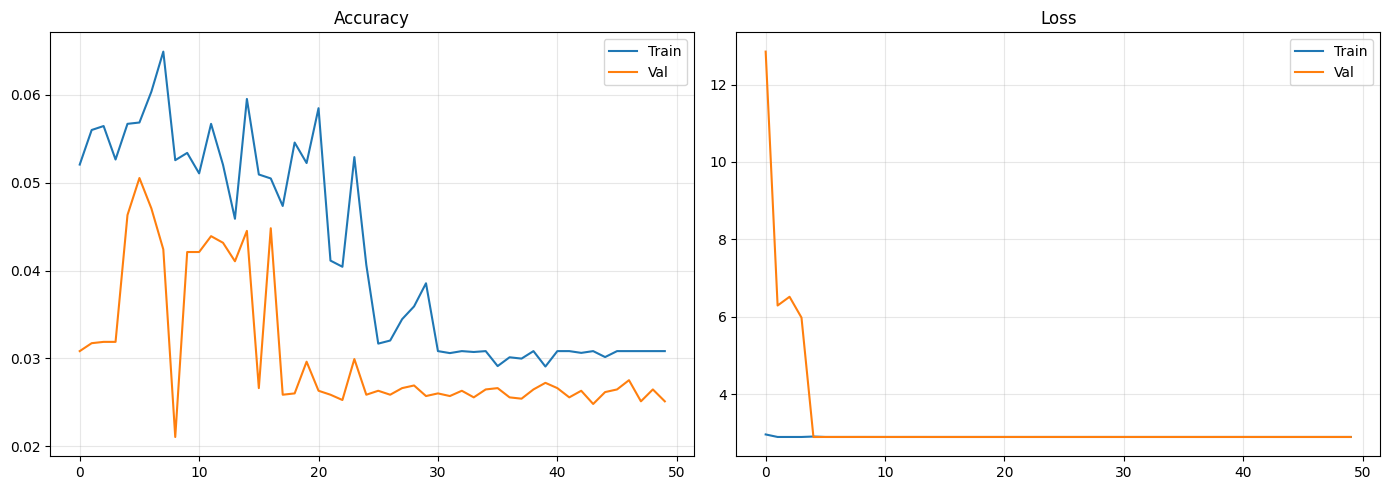

Test Accuracy: 0.0286 (2.86%)
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
              precision    recall  f1-score   support

         ain       0.00      0.00      0.00       410
        alif       0.05      0.04      0.04       307
         beh       0.00      0.00      0.00       410
         dal       0.03      0.02      0.02       205
         feh       0.15      0.06      0.09       406
         heh       0.00      0.00      0.00       408
        jeem       0.00      0.00      0.00       410
         kaf       0.00      0.00      0.00       410
         lam       0.00      0.00      0.00       513
        meem       0.03      0.00      0.00       410
        noon       0.00      0.00      0.00       406
         qaf       0.00      0.00      0.00       408
         raa       0.02      0.32      0.04       205
         sad       0.00      0.00      0.00       410
        seen       0.00      0.00      0.00       410
         tah       0.03      0.22      0.05       307
         

f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

y_pred = np.argmax(model.predict(X_test), axis=1)
present = sorted(np.unique(np.concatenate([y_test, y_pred])))
present_names = [ARABIC_LABELS[i] for i in present]
print(classification_report(y_test, y_pred, labels=present, target_names=present_names))

In [16]:
# Verify training actually occurred
print("Training History Summary:")
print(f"Initial train accuracy: {history.history['accuracy'][0]:.4f}")
print(f"Final train accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"Initial val accuracy:   {history.history['val_accuracy'][0]:.4f}")
print(f"Final val accuracy:     {history.history['val_accuracy'][-1]:.4f}")
print(f"\nInitial train loss: {history.history['loss'][0]:.4f}")
print(f"Final train loss:   {history.history['loss'][-1]:.4f}")

if history.history['accuracy'][-1] < 0.15:
    print("\n⚠️ WARNING: Model accuracy is still < 15% — model may not have trained properly!")
    print("Possible issues:")
    print("  - Data pipeline corrupted (check X_train/y_train shapes)")
    print("  - Label encoding mismatch during training vs inference")
    print("  - Model architecture too large for dataset size (16-20 samples per class)")
else:
    print(f"\n✅ Model learned: accuracy improved from {history.history['accuracy'][0]:.1%} to {history.history['accuracy'][-1]:.1%}")

Training History Summary:
Initial train accuracy: 0.0521
Final train accuracy:   0.0308
Initial val accuracy:   0.0308
Final val accuracy:     0.0251

Initial train loss: 2.9558
Final train loss:   2.8904

⚠️ WARNING: Model accuracy is still < 15% — model may not have trained properly!
Possible issues:
  - Data pipeline corrupted (check X_train/y_train shapes)
  - Label encoding mismatch during training vs inference
  - Model architecture too large for dataset size (16-20 samples per class)


In [18]:
# Load best model from checkpoint
cnn_model = load_model('best_arabic_cnn.keras')
label_classes = np.load('label_classes.npy', allow_pickle=True)

loss, acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.4f}")

# Check what it predicts across all test samples
preds = np.argmax(cnn_model.predict(X_test, verbose=0), axis=1)
from collections import Counter
print("\nPrediction distribution on test set:")
for label, count in Counter([label_classes[i] for i in preds]).most_common(10):
    print(f"  {label}: {count}")

Test accuracy: 0.0562

Prediction distribution on test set:
  tah: 2475
  sad: 2431
  yaa: 638
  feh: 380
  alif: 339
  dal: 242
  raa: 145


## 4. YOLO Training — Single-Class Character Detector
YOLO only learns to **locate** characters (1 class). CNN handles classification.
This works much better with small datasets.

In [19]:
# Convert all Label Studio labels to single class (class_id = 0)
def convert_to_single_class(dataset_dir):
    for split in ['train', 'val']:
        labels_dir = dataset_dir / split / 'labels'
        if not labels_dir.exists():
            print(f"  Skipping {split} — not found")
            continue
        count = 0
        for txt_file in labels_dir.glob('*.txt'):
            lines = txt_file.read_text().splitlines()
            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    parts[0] = '0'
                    new_lines.append(' '.join(parts))
            txt_file.write_text('\n'.join(new_lines) + '\n')
            count += 1
        print(f"  Converted {count} label files in {split}/")

print("Converting labels to single-class...")
convert_to_single_class(MY_DATASET)

# Verify dataset
train_imgs = list((MY_DATASET / 'train' / 'images').glob('*.*'))
val_imgs   = list((MY_DATASET / 'val'   / 'images').glob('*.*'))
print(f"Train images: {len(train_imgs)}")
print(f"Val images  : {len(val_imgs)}")

Converting labels to single-class...
  Converted 60 label files in train/
  Converted 13 label files in val/
Train images: 60
Val images  : 13


In [20]:
# Write single-class data.yaml
yaml_path = MY_DATASET / 'data.yaml'
with open(yaml_path, 'w') as f:
    f.write(f"path: {MY_DATASET.as_posix()}\n")
    f.write("train: train/images\n")
    f.write("val: val/images\n")
    f.write("nc: 1\n")
    f.write("names:\n")
    f.write("  - character\n")

print(open(yaml_path).read())

path: F:/newbach/Arabic-Handwritten-Characters-Recognition-using-CNN/my_dataset
train: train/images
val: val/images
nc: 1
names:
  - character



In [21]:
# Train YOLO
n_train = len(train_imgs)

yolo_model = YOLO('yolov8s.pt')
yolo_results = yolo_model.train(
    data=str(yaml_path),
    epochs=150,
    imgsz=640,
    batch=4,
    patience=30,
    device='cpu',
    project=str(ROOT / 'my_yolo'),
    name='char_detector',
    exist_ok=True,
    degrees=10.0,
    translate=0.15,
    scale=0.4,
    shear=3.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.5 if n_train >= 50 else 0.0,
    mixup=0.1  if n_train >= 50 else 0.0,
    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.4,
)

YOLO_WEIGHTS = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'
print(f"\nYOLO done. Weights exist: {YOLO_WEIGHTS.exists()}")

Ultralytics 8.4.26  Python-3.11.0 torch-2.10.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset\data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=char_detector, nbs=64, nms=False, opset=None, optimize=Fal

## 5. Inference Pipeline

In [26]:
# Load models
YOLO_WEIGHTS = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'

cnn_model     = load_model('best_arabic_cnn.keras')  # reload best checkpoint
yolo_detector = YOLO(str(YOLO_WEIGHTS))
label_classes = np.load('label_classes.npy', allow_pickle=True)

print(f"CNN loaded")
print(f"YOLO loaded: {YOLO_WEIGHTS}")
print(f"Classes: {len(label_classes)}")

CNN loaded
YOLO loaded: F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\my_yolo\char_detector\weights\best.pt
Classes: 18


In [27]:
# Debug: verify label_classes.npy matches training
print("label_classes.npy contents:")
print(label_classes)
print(f"\nARABIC_LABELS from training:")
print(ARABIC_LABELS)
print(f"\nMatch: {np.array_equal(label_classes, ARABIC_LABELS)}")
print(f"\nIf mismatch, label_classes.npy is stale. Regenerate now:")
np.save("label_classes.npy", ARABIC_LABELS)
print("Saved fresh label_classes.npy")

label_classes.npy contents:
['ain' 'alif' 'beh' 'dal' 'feh' 'heh' 'jeem' 'kaf' 'lam' 'meem' 'noon' 'qaf' 'raa' 'sad' 'seen' 'tah' 'waw' 'yaa']

ARABIC_LABELS from training:
[np.str_('ain'), np.str_('alif'), np.str_('beh'), np.str_('dal'), np.str_('feh'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('raa'), np.str_('sad'), np.str_('seen'), np.str_('tah'), np.str_('waw'), np.str_('yaa')]

Match: True

If mismatch, label_classes.npy is stale. Regenerate now:
Saved fresh label_classes.npy


In [28]:
def preprocess_for_cnn(crop_bgr, img_size=IMG_SIZE):
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    # Otsu threshold — critical for cleaning up the crop
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # Tight bounding box around ink
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return None
    x, y, w, h = cv2.boundingRect(coords)
    roi = thresh[y:y+h, x:x+w]
    # Square pad with margin
    side = int(max(h, w) * 1.3)
    if side == 0:
        return None
    canvas = np.zeros((side, side), dtype='uint8')
    ox, oy = (side - w) // 2, (side - h) // 2
    canvas[oy:oy+h, ox:ox+w] = roi
    resized = cv2.resize(canvas, (img_size, img_size), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0
    return normalized[..., np.newaxis]


def recognize_word(image_path, conf_threshold=0.25, iou_threshold=0.4):
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    H, W = img.shape[:2]
    annotated = img.copy()

    # YOLO — find character boxes (single class)
    results = yolo_detector(img, conf=conf_threshold, iou=iou_threshold, verbose=False)[0]
    boxes = results.boxes

    if len(boxes) == 0:
        print("No characters detected.")
        return [], [], annotated

    detections = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1c, y1c = max(0, x1), max(0, y1)
        x2c, y2c = min(W, x2), min(H, y2)
        crop = img[y1c:y2c, x1c:x2c]
        if crop.size == 0:
            continue

        # CNN — classify the crop
        proc = preprocess_for_cnn(crop)
        if proc is None:
            continue
        preds = cnn_model.predict(np.expand_dims(proc, axis=0), verbose=0)[0]
        cnn_idx  = np.argmax(preds)
        cnn_conf = float(preds[cnn_idx])
        full_label = str(label_classes[cnn_idx])          # e.g. beh or beh_beginning
        if '_' in full_label:
            base_label = full_label.rsplit('_', 1)[0]
        else:
            base_label = full_label

        detections.append((x1, y1, x2, y2, full_label, base_label, cnn_conf))

    # Sort right-to-left
    detections.sort(key=lambda d: -d[0])

    full_labels, base_labels = [], []
    for (x1, y1, x2, y2, full, base, conf) in detections:
        full_labels.append(full)
        base_labels.append(base)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(annotated, f"{base} {conf:.0%}",
                    (x1, max(0, y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 200, 0), 1)

    return base_labels, full_labels, annotated


print("Inference pipeline ready.")

Inference pipeline ready.


In [29]:
def segment_characters(image, min_char_width=10, max_char_width=100):
    """
    Simple character segmentation using vertical projection.
    Assumes the image is a binary word image with white text on black background.
    """
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Threshold to binary
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert if text is black
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)

    # Vertical projection (sum along rows)
    projection = np.sum(binary, axis=0) / 255.0

    # Find character boundaries
    char_starts = []
    char_ends = []
    in_char = False
    for i, val in enumerate(projection):
        if val > 0 and not in_char:
            char_starts.append(i)
            in_char = True
        elif val == 0 and in_char:
            char_ends.append(i)
            in_char = False
    if in_char:
        char_ends.append(len(projection))

    # Filter by width
    characters = []
    for start, end in zip(char_starts, char_ends):
        width = end - start
        if min_char_width <= width <= max_char_width:
            char_img = binary[:, start:end]
            characters.append((start, end, char_img))

    return characters


def recognize_word_with_segmentation(image_path, conf_threshold=0.25):
    """
    Alternative recognition using simple segmentation instead of YOLO.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    H, W = img.shape[:2]
    annotated = img.copy()

    # Segment characters
    characters = segment_characters(img)

    if len(characters) == 0:
        print("No characters segmented.")
        return [], [], annotated

    detections = []
    for start, end, char_img in characters:
        # Resize char_img to 64x64 for CNN
        resized = cv2.resize(char_img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        normalized = resized.astype('float32') / 255.0
        proc = normalized[..., np.newaxis]

        # CNN classify
        preds = cnn_model.predict(np.expand_dims(proc, axis=0), verbose=0)[0]
        cnn_idx = np.argmax(preds)
        cnn_conf = float(preds[cnn_idx])
        pred_label = str(label_classes[cnn_idx])

        # For annotation, assume full width
        x1, y1, x2, y2 = start, 0, end, H
        detections.append((x1, y1, x2, y2, pred_label, pred_label, cnn_conf))

    # Sort right-to-left
    detections.sort(key=lambda d: -d[0])

    base_labels = [d[5] for d in detections]
    full_labels = base_labels

    for (x1, y1, x2, y2, _, base, conf) in detections:
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(annotated, f"{base} {conf:.0%}",
                    (x1, max(0, y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 200, 0), 1)

    return base_labels, full_labels, annotated


print("Segmentation function added.")

Segmentation function added.


Letters (simple): sad sad sad
Letters (with form): sad sad sad


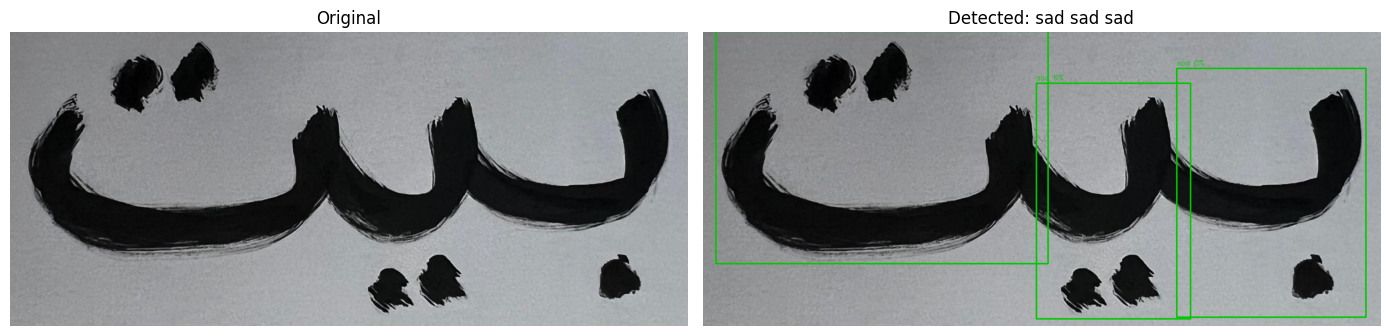

In [30]:
# ── Test on a single image ────────────────────────────────────
# Change this to any word image you want to test
TEST_IMAGE = str(ROOT / 'word_test.png')

base_chars, full_chars, annotated_img = recognize_word(
    TEST_IMAGE, conf_threshold=0.25, iou_threshold=0.4
)

print(f"Letters (simple): {' '.join(base_chars)}")
print(f"Letters (with form): {' '.join(full_chars)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(TEST_IMAGE), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected: {" ".join(base_chars)}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [36]:
loss, acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.4f}")

Test accuracy: 0.0562


No characters segmented.
Letters (segmentation): 


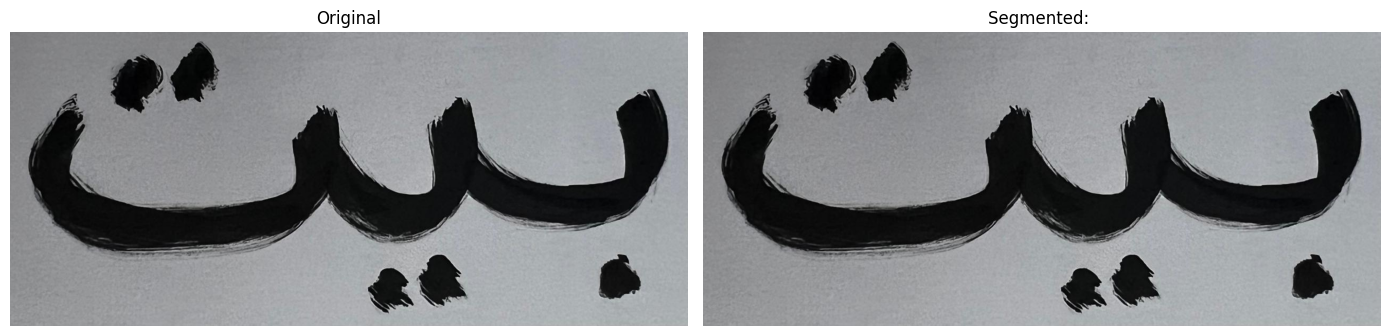

In [31]:
# ── Test segmentation-based recognition ────────────────────────────────────
# Change this to any word image you want to test
TEST_IMAGE_SEG = str(ROOT / 'word_test.png')

base_chars_seg, full_chars_seg, annotated_img_seg = recognize_word_with_segmentation(
    TEST_IMAGE_SEG, conf_threshold=0.25
)

print(f"Letters (segmentation): {' '.join(base_chars_seg)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(TEST_IMAGE_SEG), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated_img_seg, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Segmented: {" ".join(base_chars_seg)}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [32]:
# Debug: Show crops and predictions for a single image
def debug_recognize_word(image_path, conf_threshold=0.25, iou_threshold=0.4):
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    H, W = img.shape[:2]
    annotated = img.copy()

    # YOLO — find character boxes
    results = yolo_detector(img, conf=conf_threshold, iou=iou_threshold, verbose=False)[0]
    boxes = results.boxes

    if len(boxes) == 0:
        print("No characters detected.")
        return

    print(f"Detected {len(boxes)} characters")

    # Show each crop and prediction
    fig, axes = plt.subplots(1, len(boxes), figsize=(3*len(boxes), 3))
    if len(boxes) == 1:
        axes = [axes]

    detections = []
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1c, y1c = max(0, x1), max(0, y1)
        x2c, y2c = min(W, x2), min(H, y2)
        crop = img[y1c:y2c, x1c:x2c]
        if crop.size == 0:
            continue

        # CNN classify
        proc = preprocess_for_cnn(crop)
        preds = cnn_model.predict(np.expand_dims(proc, axis=0), verbose=0)[0]
        cnn_idx = np.argmax(preds)
        cnn_conf = float(preds[cnn_idx])
        pred_label = str(label_classes[cnn_idx])

        print(f"Crop {i+1}: Predicted '{pred_label}' with {cnn_conf:.1%} confidence")

        # Show crop
        axes[i].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Pred: {pred_label}\nConf: {cnn_conf:.1%}")
        axes[i].axis('off')

        detections.append((x1, y1, x2, y2, pred_label, cnn_conf))

    plt.tight_layout()
    plt.show()

    # Sort and show final word
    detections.sort(key=lambda d: -d[0])  # right to left
    word = ' '.join([d[4] for d in detections])
    print(f"Final word: {word}")

# Test debug on first val image
if val_images:
    debug_recognize_word(str(val_images[0]))

NameError: name 'val_images' is not defined

In [33]:
# Debug: check model predictions on test set
print("Model predictions on test set (first 50):")
test_preds = cnn_model.predict(X_test[:50], verbose=0)
pred_indices = np.argmax(test_preds, axis=1)
pred_labels = [label_classes[i] for i in pred_indices]
pred_confidences = np.max(test_preds, axis=1)

from collections import Counter
pred_counts = Counter(pred_labels)
print(f"\nPrediction distribution (first 50 test samples):")
for label, count in pred_counts.most_common():
    print(f"  {label}: {count}")
print(f"\nConfidences (first 10): {pred_confidences[:10]}")
print(f"Mean confidence: {pred_confidences.mean():.3f}")

# If all predictions are one class with high confidence, the model is overfit/broken
if len(pred_counts) == 1:
    print(f"\n⚠️ WARNING: Model predicts ONLY '{list(pred_counts.keys())[0]}' on all test samples!")
    print("Likely causes:")
    print("  1. label_classes.npy is stale (reloaded old label order)")
    print("  2. Training data was heavily imbalanced towards that class")
    print("  3. Model needs retraining with fresh data splits")

Model predictions on test set (first 50):

Prediction distribution (first 50 test samples):
  sad: 15
  tah: 15
  yaa: 9
  alif: 5
  feh: 5
  dal: 1

Confidences (first 10): [   0.056513    0.067868    0.055888    0.060889    0.055947    0.058215    0.057719    0.063273    0.069337    0.059414]
Mean confidence: 0.058


In [34]:
# Debug: check my_chars subfolders and counts
from pathlib import Path
my_chars_dir = Path(r"F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\my_chars")
subdirs = sorted([p for p in my_chars_dir.iterdir() if p.is_dir()])
print('subdirs:', [p.name for p in subdirs])
for p in subdirs:
    print(p.name, len(list(p.glob('*.png'))))

subdirs: ['ain', 'alif', 'beh', 'dad', 'dal', 'feh', 'ghain', 'hah', 'hamza', 'heh', 'jeem', 'kaf', 'khah', 'lam', 'meem', 'noon', 'qaf', 'raa', 'sad', 'seen', 'sheen', 'tah', 'teh', 'thal', 'theh', 'waw', 'yaa', 'zah', 'zain']
ain 8
alif 10
beh 22
dad 4
dal 7
feh 6
ghain 3
hah 8
hamza 3
heh 5
jeem 6
kaf 5
khah 3
lam 17
meem 18
noon 10
qaf 7
raa 20
sad 5
seen 10
sheen 4
tah 4
teh 8
thal 2
theh 3
waw 7
yaa 8
zah 4
zain 3


Testing on 13 val images...

ce0882a8-WhatsApp_Image_2026-03-23_at_2.21.24_AM_8.jpeg: sad sad sad


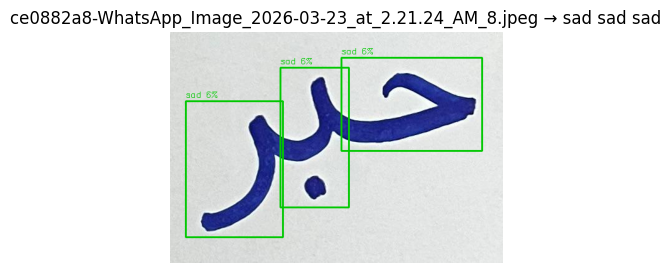

d272ef07-WhatsApp_Image_2026-03-23_at_2.21.26_AM_25.jpeg: sad sad sad


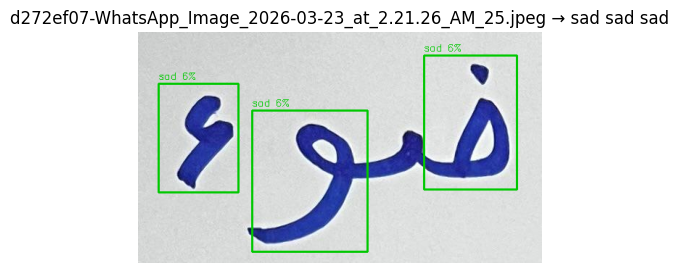

da1fee74-WhatsApp_Image_2026-03-23_at_2.21.26_AM_18.jpeg: sad sad sad


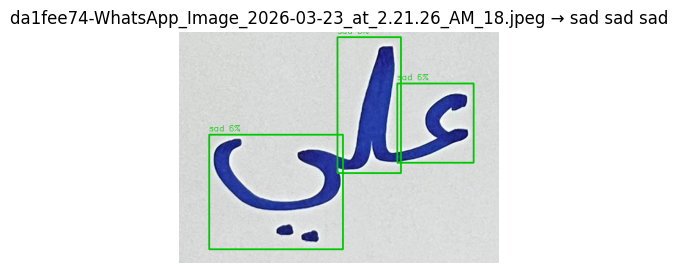

dd921431-WhatsApp_Image_2026-03-23_at_2.21.26_AM_20.jpeg: sad sad sad sad sad


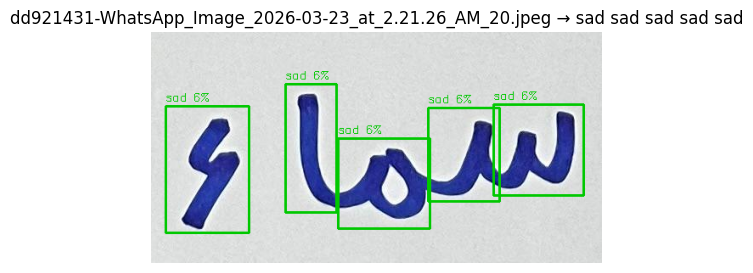

e05f66fa-WhatsApp_Image_2026-03-23_at_2.21.26_AM_9.jpeg: sad sad sad


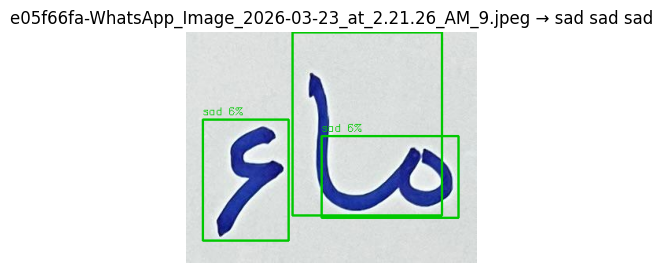

e47bdbbb-WhatsApp_Image_2026-03-23_at_2.21.26_AM_47.jpeg: sad sad


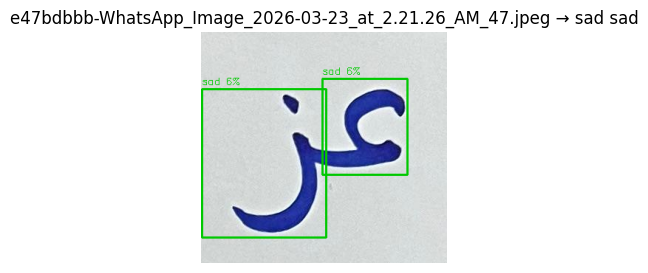

e8f36542-WhatsApp_Image_2026-03-23_at_2.21.26_AM_21.jpeg: sad sad sad


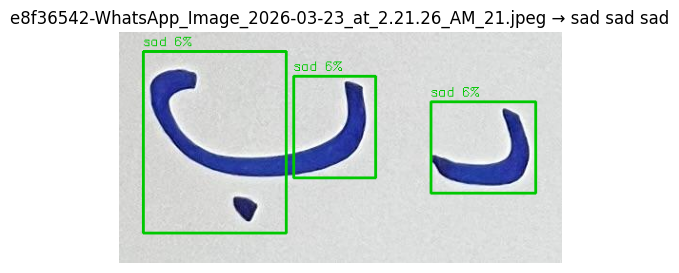

ee3eef31-WhatsApp_Image_2026-03-23_at_2.21.26_AM_40.jpeg: sad sad sad


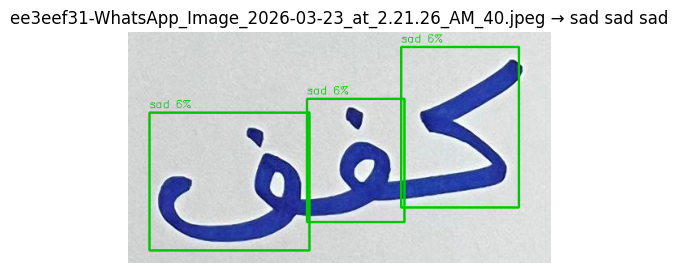

ef978434-WhatsApp_Image_2026-03-23_at_2.21.24_AM_1.jpeg: sad sad sad


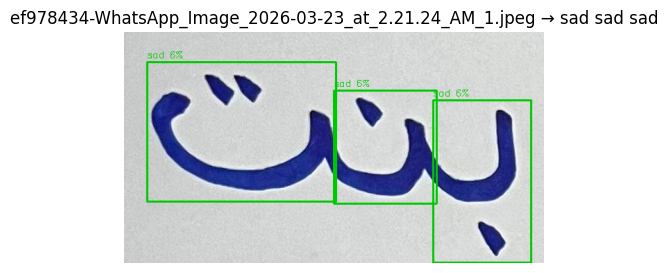

f1769f84-WhatsApp_Image_2026-03-23_at_2.21.26_AM_11.jpeg: sad sad sad


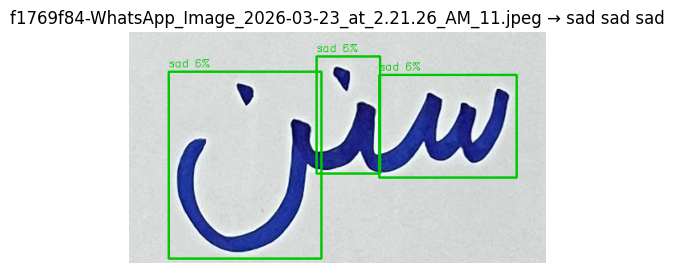

In [35]:
# ── Test on all val images ────────────────────────────────────
val_images = list((MY_DATASET / 'val' / 'images').glob('*.*'))
print(f"Testing on {len(val_images)} val images...\n")

for img_path in val_images[:10]:
    try:
        base_chars, _, annotated = recognize_word(str(img_path))
        print(f"{img_path.name}: {' '.join(base_chars)}")
        plt.figure(figsize=(8, 3))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"{img_path.name} → {' '.join(base_chars)}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error on {img_path.name}: {e}")